In [15]:
from calculos_plasmas import *
import matplotlib.pyplot as plt

def analizar_autovalores(plasma : Plasma, titulo="Comparación de Autovalores"):
    """
    Compara las energías numéricas de un objeto Plasma con las analíticas del Hidrógeno.
    """
    if plasma.E_0 is None:
        raise ValueError("Todavía no se han computado los autovalores.")

    n_values = [1]
    E_num = [plasma.E_0]
    E_ana = [-0.5*E_h*plasma.Z**2]

    for l in range(1, len(plasma.E_l)):
        E_l = plasma.E_l[l]
        n_start = l + 1 if l > 0 else 2

        for i, E_nl in enumerate(E_l):
            n = n_start + i
            n_values.append(n)
            E_num.append(E_nl)
            E_ana.append(-0.5*E_h*plasma.Z**2 / n**2)

    n_values = np.array(n_values)
    E_num_eV = np.array(E_num) / e
    E_ana_eV = np.array(E_ana) / e

    mse_eV = np.mean((E_num_eV - E_ana_eV)**2)

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, E_ana_eV, 'kx', markersize=10, label='Analítico')
    plt.plot(n_values, E_num_eV, 'ro', alpha=0.7, label=f'Numérico')

    plt.title(f"{titulo}\nDistancia Cuadrática Media: {mse_eV:.2e} $eV^2$")
    plt.xlabel("Número cuántico principal ($n$)")
    plt.ylabel("Energía (eV)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    return mse_eV

Vamos a simular un plasma A sin cuyo potencial no considera efectos de plasma

In [16]:
A = Plasma()
A.set_temperature(1, "eV")
A.set_electron_density(1e18, "cm")
A.set_atomic_mesh(2e3)
A.solve_schrodinger(plasma_effects=False)

Ahora veremos si el resultado teórico conocido coincide con la simulación:
$$
E_n = \frac{Z^2}{2n^2}E_H
$$
y haremos una medida del error cuadrático medio.

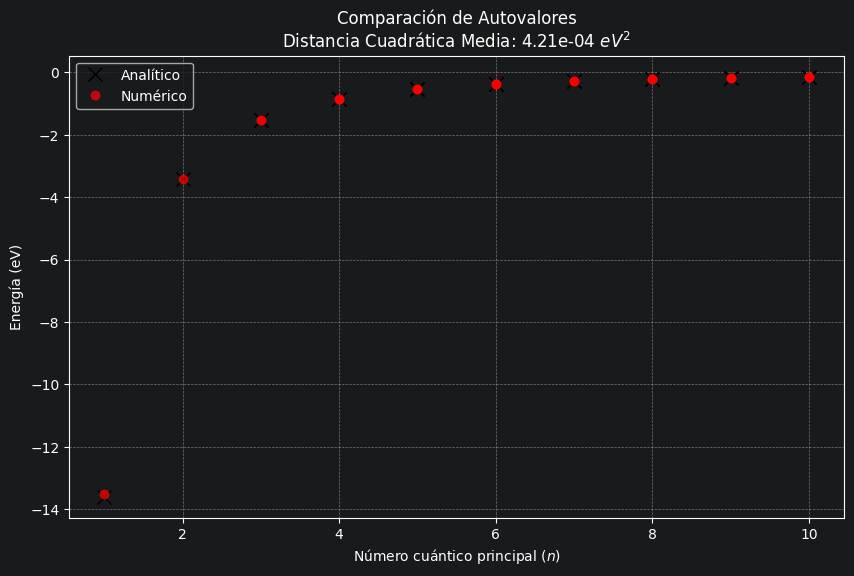

np.float64(0.00042134643915284984)

In [17]:
analizar_autovalores(A)